In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, LSTM, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and config
dataset_path = "/content/drive/MyDrive/split_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

#  Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 2280 images belonging to 34 classes.
Found 656 images belonging to 34 classes.
Found 345 images belonging to 34 classes.


In [3]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenetv2_gru_model.h5")


In [ ]:
from google.colab import files

print(" Upload source image (current location)")
uploaded_source = files.upload()

print(" Upload destination image")
uploaded_dest = files.upload()

 Upload source image (current location)


Saving I1_00057.jpg to I1_00057.jpg
 Upload destination image


Saving chancellor_00026.jpg to chancellor_00026.jpg


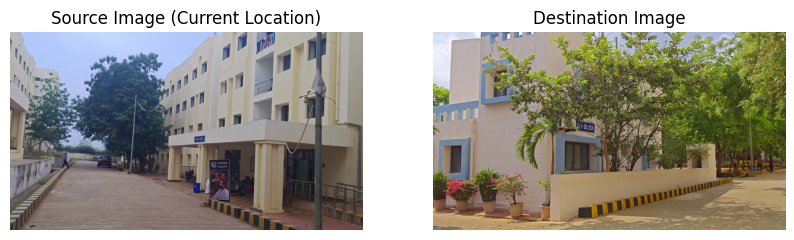

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


import tensorflow as tf
model_path = "/content/drive/MyDrive/mobilenetv2_gru_model.h5"
model = tf.keras.models.load_model(model_path)

source_img_path = list(uploaded_source.keys())[0]
destination_img_path = list(uploaded_dest.keys())[0]


def preprocess_img(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

source_img_array = preprocess_img(source_img_path)
destination_img_array = preprocess_img(destination_img_path)

#  Display images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image.load_img(source_img_path))
axes[0].set_title("Source Image (Current Location)")
axes[0].axis("off")

axes[1].imshow(image.load_img(destination_img_path))
axes[1].set_title("Destination Image")
axes[1].axis("off")

plt.show()

In [ ]:
#  Predict source location
source_prediction = model.predict(source_img_array)
source_class = list(train_generator.class_indices.keys())[np.argmax(source_prediction)]

#  Predict destination location
destination_prediction = model.predict(destination_img_array)
destination_class = list(train_generator.class_indices.keys())[np.argmax(destination_prediction)]

#  Display predicted locations
print(f" Predicted Source: {source_class}")
print(f" Predicted Destination: {destination_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
 Predicted Source: I1 boys hostel
 Predicted Destination: chancellor office


In [4]:
import numpy as np

class_names = list(train_generator.class_indices.keys())
np.save("class_names.npy", class_names)


In [5]:
class_names

[' central library',
 ' k2 ground',
 ' nuzvid clinic',
 'I1 boys hostel',
 'I2 boys hostel',
 'I3 adminstrative block',
 'academic block 1(ab1)',
 'academic block 3(ab3)',
 'academic block2(ab2)',
 'beta cluster',
 'boys mess',
 'chancellor office',
 'dh1&2',
 'dh3',
 'dh4',
 'eta cluster',
 'food court',
 'gama cluster',
 'girls mess',
 'k2 girls hostel',
 'k3 girls hostel',
 'k4 girls hostel',
 'kappa cluster',
 'lambda cluster',
 'mue cluster',
 'nuzvid gate',
 'omega cluster',
 'p1 faculty block',
 'p2 faculty block',
 'p3 faculty block',
 'sac',
 'sbi',
 'sklm gate',
 'yoga shala']

In [6]:
from google.colab import files
files.download("class_names.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>